### Stata setup init and data loading

In [3]:
from statasetup import *

In [27]:
%%stata
use "Datasets/PlannedEnv_Spain_India", clear

### 1. Describing data
##### Getting a **general overview** of the content a categorical variable holds by using commands such as `codebook` or tabular form of the same overview `tab`. The argument `m` is providing the frequency/count of the missing values as well

In [30]:
%%stata
codebook country
tab country, m


. codebook country

-------------------------------------------------------------------------------
country                                                             (unlabeled)
-------------------------------------------------------------------------------

                  Type: Numeric (double)
                 Label: country2

                 Range: [1,2]                         Units: 1
         Unique values: 2                         Missing .: 1/400

            Tabulation: Freq.   Numeric  Label
                          199         1  Spain
                          200         2  India
                            1         .  

. tab country, m

    country |      Freq.     Percent        Cum.
------------+-----------------------------------
      Spain |        199       49.75       49.75
      India |        200       50.00       99.75
          . |          1        0.25      100.00
------------+-----------------------------------
      Total |        400      100.00

##### **Counting** the number of missing values

In [41]:
%%stata
list id country individualism if individualism >=.
list count individualism if individualism >=.


. list id country individualism if individualism >=.

     +---------------------------+
     |   id   country   indivi~m |
     |---------------------------|
 49. | 1049     Spain         .a |
 79. | 1079     Spain          . |
     +---------------------------+

. list count individualism if individualism >=.

     +--------------------+
     | country   indivi~m |
     |--------------------|
 49. |   Spain         .a |
 79. |   Spain          . |
     +--------------------+

. 


##### **Geting an extensive overview** by using `sum var, d`. This can be used to test normality assumptions (**kurtosis**, **skewness**)

In [61]:
%%stata
sum individualism, d
sum individualism if country==1, detail
sum individualism if country!=1, detail


. sum individualism, d

                        individualism
-------------------------------------------------------------
      Percentiles      Smallest
 1%          .09            .06
 5%          .17            .08
10%          .25            .08       Obs                 398
25%          .48            .09       Sum of wgt.         398

50%          .92                      Mean           1.011457
                        Largest       Std. dev.      .6555355
75%         1.38           3.46
90%         1.84           3.68       Variance       .4297268
95%         2.17           3.68       Skewness       1.227526
99%         3.46           4.54       Kurtosis       5.936006

. sum individualism if country==1, detail

                        individualism
-------------------------------------------------------------
      Percentiles      Smallest
 1%          .08            .06
 5%          .13            .08
10%          .17            .08       Obs                 197
25%       

##### Display things


. hist individualism, normal title("Individualism variable histogram") saving(b
> oth, replace)
(bin=19, start=.06, width=.23578947)


file both.gph saved

. hist individualism if country == 1, normal title("Spain overview through hist
> ") saving(spain, replace)
(bin=14, start=.06, width=.32)
(file spain.gph not found)
file spain.gph saved

. hist individualism if country == 2, normal title("Spain overview through hist
> ") saving(india, replace)
(bin=14, start=.24, width=.24571429)
(file india.gph not found)
file india.gph saved

. 


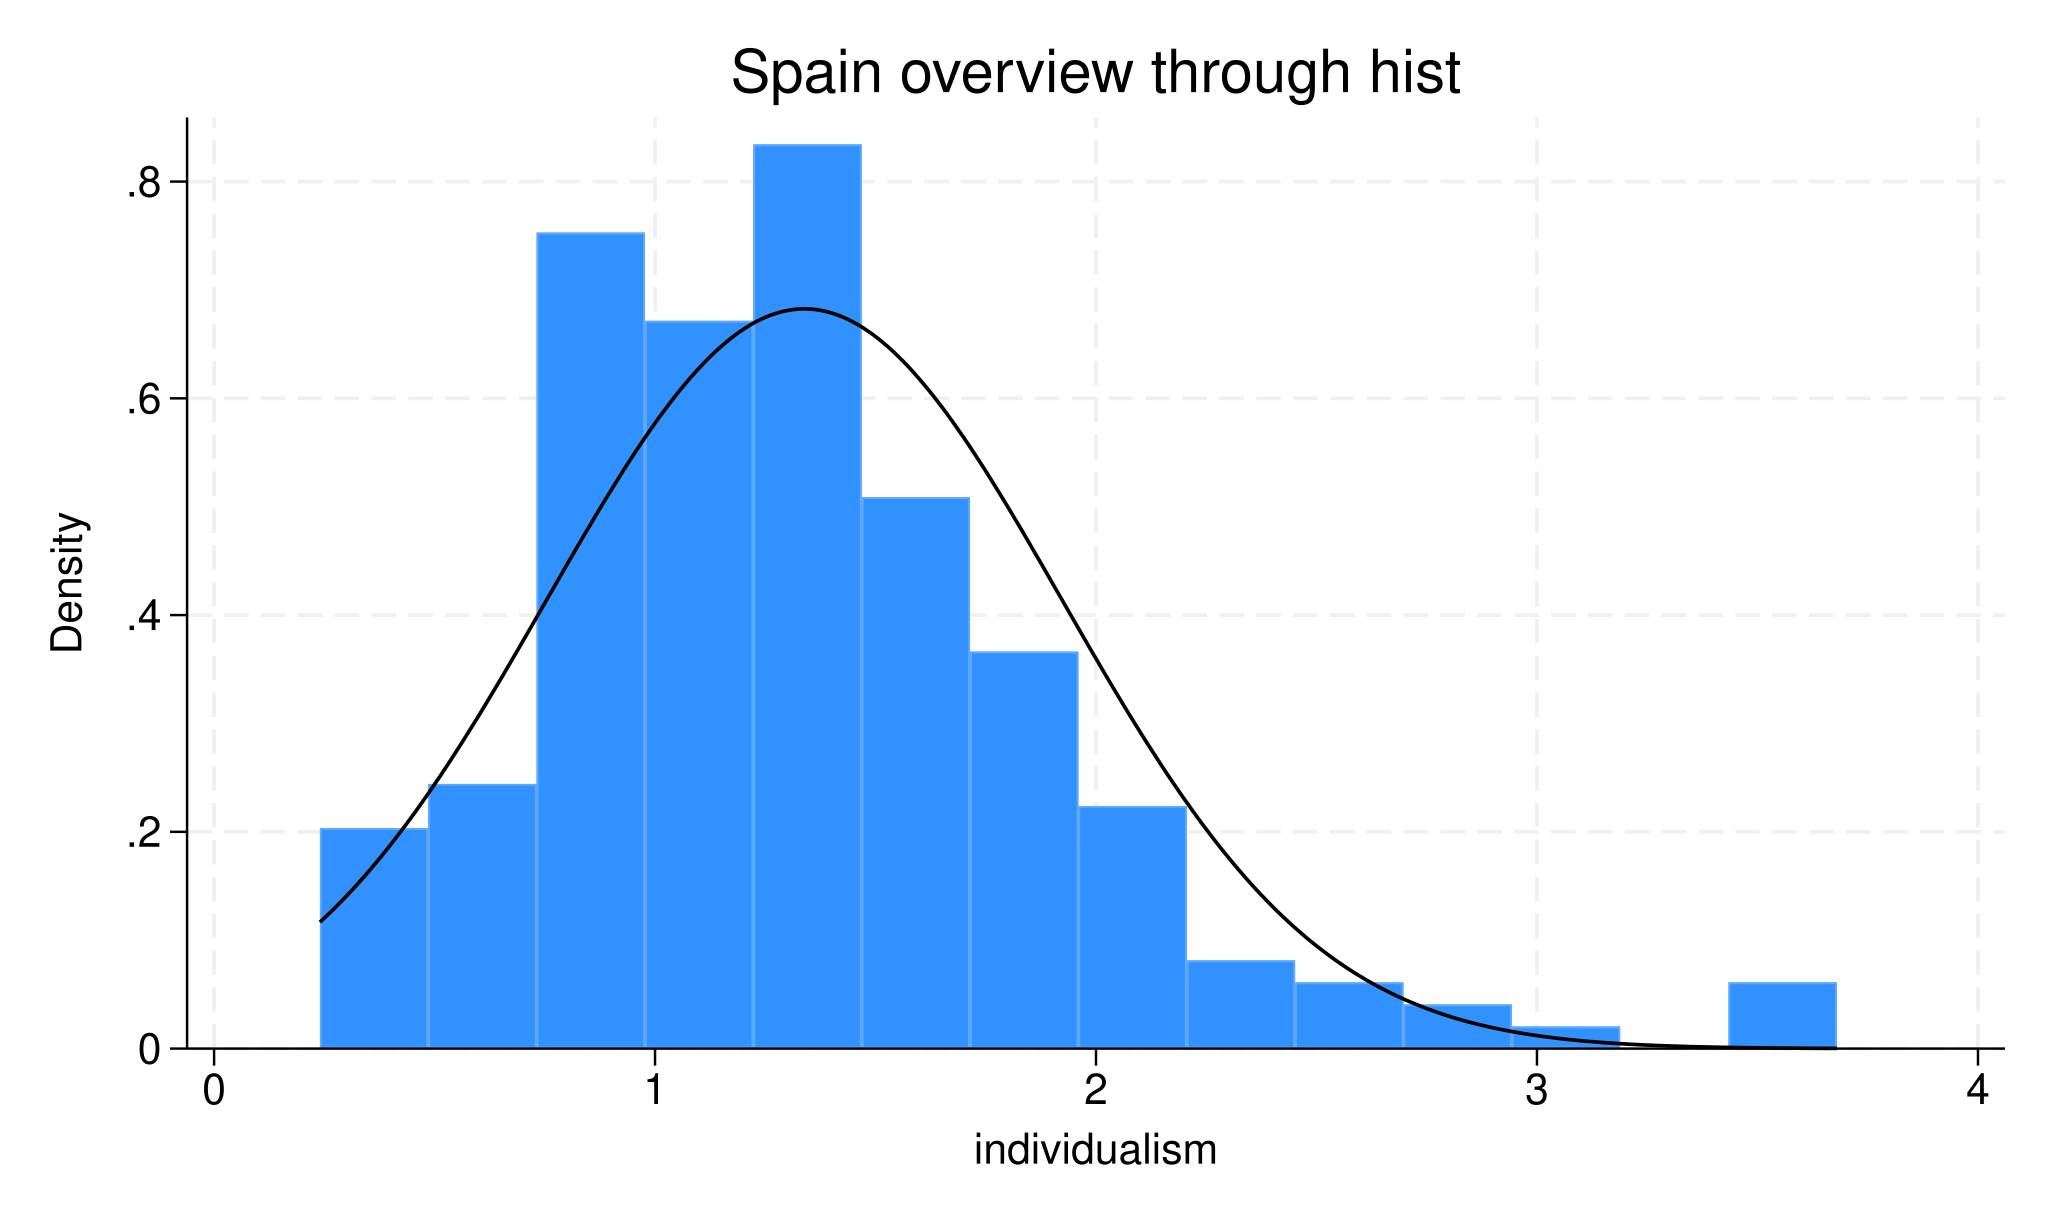

In [73]:
%%stata
hist individualism, normal title("Individualism variable histogram") saving(both, replace)
hist individualism if country == 1, normal title("Spain overview through hist") saving(spain, replace)
hist individualism if country == 2, normal title("Spain overview through hist") saving(india, replace)

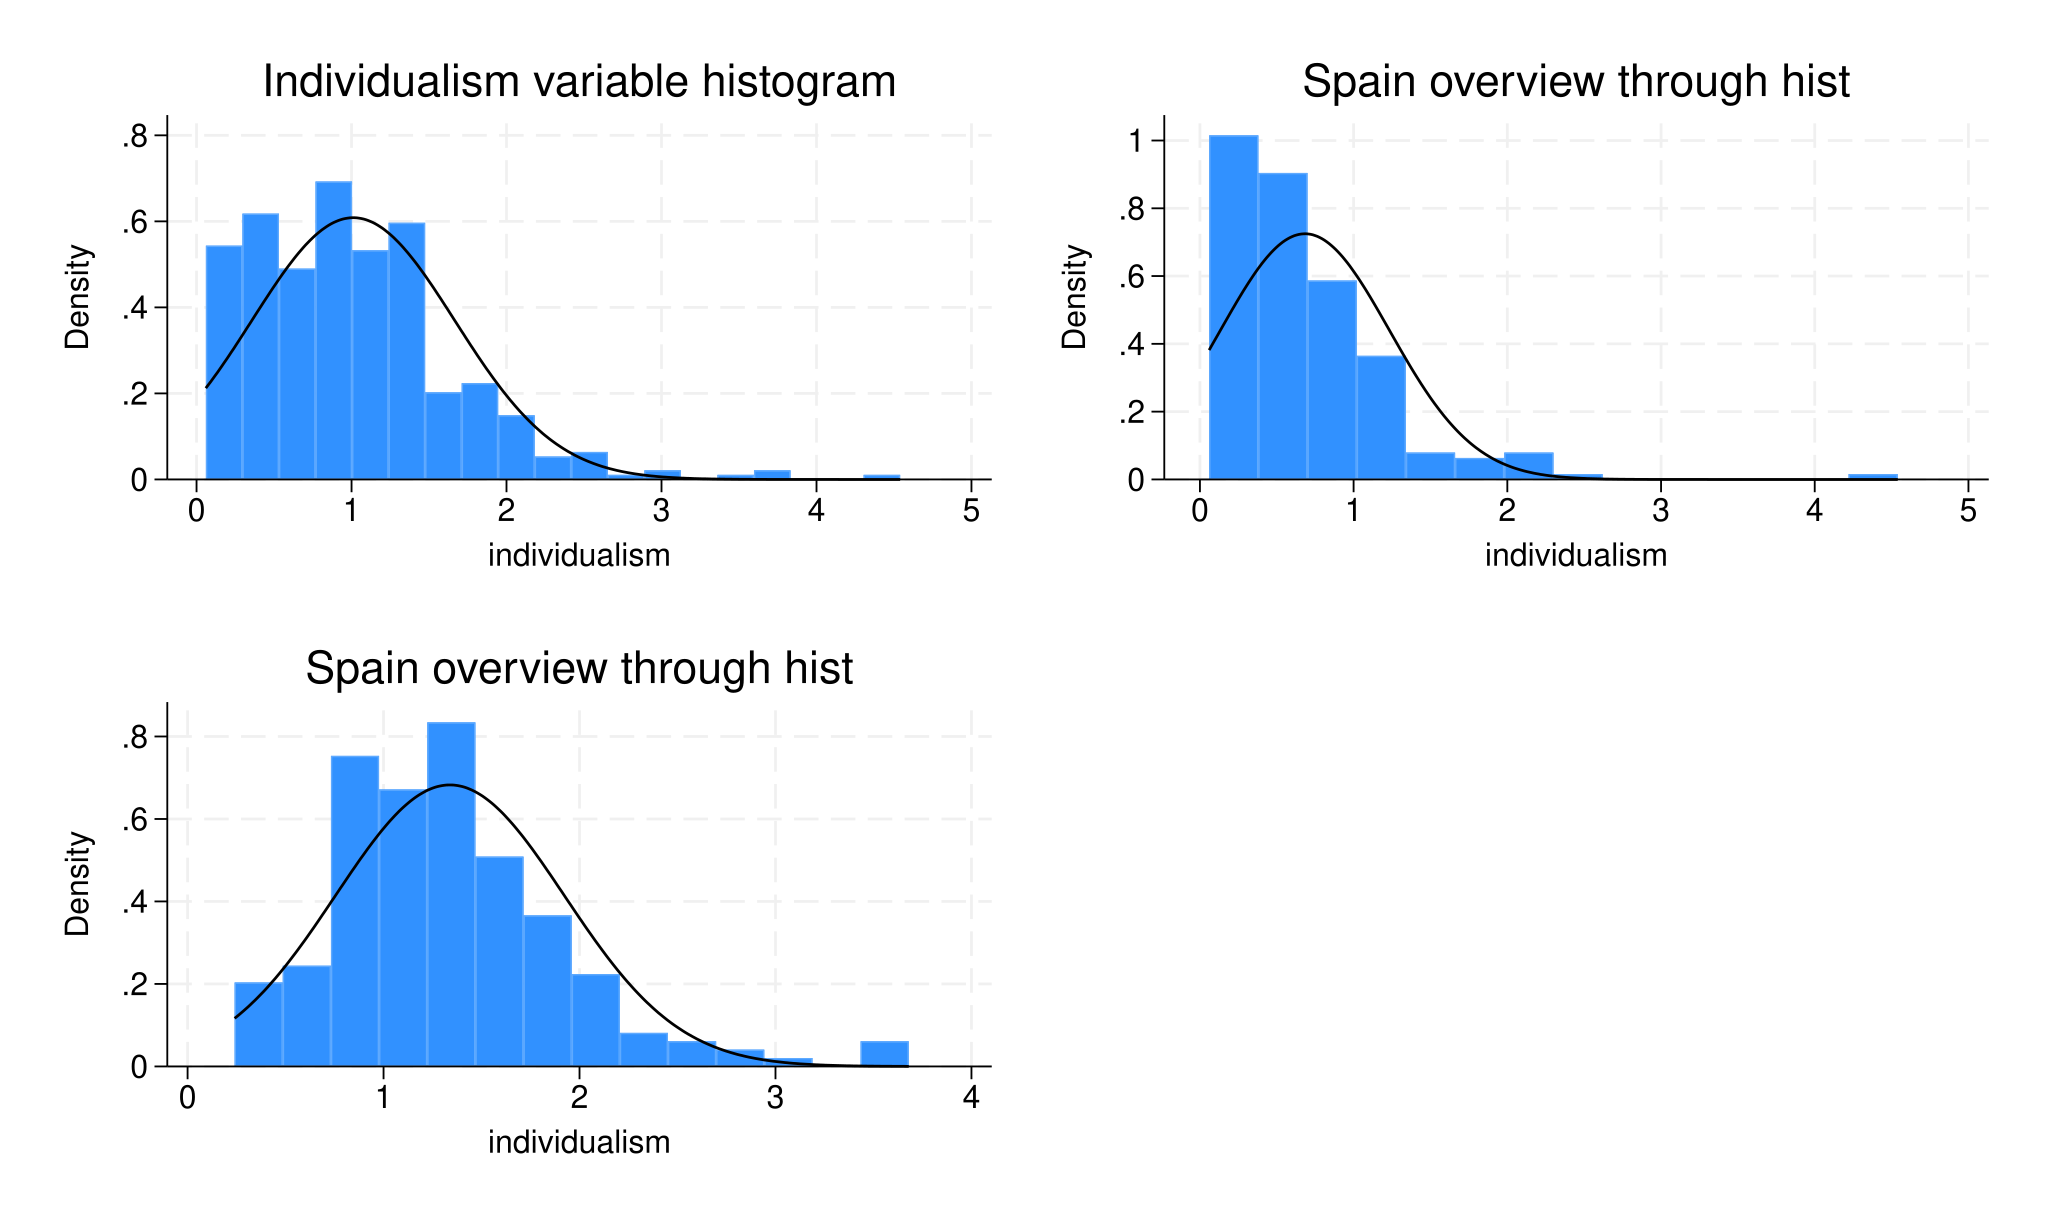

In [74]:
%%stata
gr combine both.gph spain.gph india.gph